# 00 · EDA — Exploração dos dados

Espaço para conhecer os dados brutos antes de qualquer modelagem.

> Este notebook é **exploratório** e **não faz parte do pipeline executável** (`scripts/run_pipeline.py` o ignora). Ele não escreve artefatos consumidos pelas etapas seguintes.
>
> Plano: [`docs/eda/README.md`](../docs/eda/README.md) · tarefas: [`docs/eda/tarefas.md`](../docs/eda/tarefas.md).
> **Escopo: todos os CSV de `data/raw/` exceto `worldcup-2026-results.csv` (gabarito de avaliação).**

In [1]:
# Setup: resolve a raiz do repositório e os caminhos de dados.
from pathlib import Path

def find_root(start: Path | None = None) -> Path:
    base = (start or Path.cwd()).resolve()
    for cand in [base, *base.parents]:
        if (cand / "data" / "raw").is_dir() and (cand / "pyproject.toml").is_file():
            return cand
    raise RuntimeError("Raiz do repositório não encontrada a partir de " + str(base))

ROOT = find_root()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"
MODELS = ROOT / "models"
print("ROOT:", ROOT)

ROOT: /Users/franklaercio/Workspace/paul-the-octopus


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
np.random.seed(7)

historico = pd.read_csv(RAW / "historical-results.csv", parse_dates=["date"])
ranking = pd.read_csv(RAW / "ranking.csv", parse_dates=["rank_date"])
calendario = pd.read_csv(RAW / "matches-schedule.csv")
shootouts = pd.read_csv(RAW / "shootouts.csv", parse_dates=["date"])
h2h = pd.read_csv(RAW / "historical_win-loose-draw_ratios.csv")

# ATENÇÃO: worldcup-2026-results.csv NÃO é carregado de propósito (gabarito de avaliação).
datasets = {"historico": historico, "ranking": ranking, "calendario": calendario,
            "shootouts": shootouts, "h2h": h2h}
{nome: df.shape for nome, df in datasets.items()}

{'historico': (49402, 9),
 'ranking': (68973, 8),
 'calendario': (72, 7),
 'shootouts': (677, 4),
 'h2h': (798, 6)}

## §5.1 · Ingestão e panorama (E0)

Visão geral de cada arquivo: forma, tipos, nulos e exemplo — um **dicionário de dados** rápido antes de explorar.

In [3]:
def dicionario(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(),
        "exemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })

for nome, df in datasets.items():
    print(f"=== {nome}  {df.shape} ===")
    display(dicionario(df))

=== historico  (49402, 9) ===


,tipo,n_nulos,pct_nulos,n_unicos,exemplo
date,datetime64[us],0,0.0,16453,1872-11-30 00:00:00
home_team,str,0,0.0,329,Scotland
away_team,str,0,0.0,322,England
home_score,int64,0,0.0,26,0
away_score,int64,0,0.0,22,0
tournament,str,0,0.0,200,Friendly
city,str,0,0.0,2143,Glasgow
country,str,0,0.0,270,Scotland
neutral,bool,0,0.0,2,False


=== ranking  (68973, 8) ===


,tipo,n_nulos,pct_nulos,n_unicos,exemplo
rank,float64,21,0.03,211,1.0
country_full,str,0,0.00,223,Germany
country_abrv,str,0,0.00,217,GER
total_points,float64,0,0.00,6308,57.0
previous_points,float64,0,0.00,6141,0.0
rank_change,int64,0,0.00,122,0
confederation,str,0,0.00,6,UEFA
rank_date,datetime64[us],0,0.00,346,1992-12-31 00:00:00


=== calendario  (72, 7) ===


,tipo,n_nulos,pct_nulos,n_unicos,exemplo
match,int64,0,0.0,72,1
date,str,0,0.0,17,11/06/2026
time_brasilia,str,0,0.0,14,16:00
timezone,str,0,0.0,1,GMT-3
home,str,0,0.0,48,Mexico
away,str,0,0.0,45,South Africa
phase,str,0,0.0,1,group matches


=== shootouts  (677, 4) ===


,tipo,n_nulos,pct_nulos,n_unicos,exemplo
date,datetime64[us],0,0.0,592,1967-08-22 00:00:00
home_team,str,0,0.0,188,India
away_team,str,0,0.0,198,Chinese Taipei
winner,str,0,0.0,182,Chinese Taipei


=== h2h  (798, 6) ===


,tipo,n_nulos,pct_nulos,n_unicos,exemplo
home,str,0,0.0,31,Argentina
away,str,0,0.0,31,Australia
games,int64,0,0.0,50,7
wins,float64,0,0.0,133,0.714286
looses,float64,0,0.0,133,0.142857
draws,float64,0,0.0,78,0.142857


## §5.2 · Auditoria de qualidade (E1)

Procurar problemas antes que virem conclusões falsas: faixas, datas, duplicatas e consistências específicas.

In [4]:
print("Período histórico:", historico.date.min().date(), "->", historico.date.max().date())
print("Placares negativos:", int(((historico.home_score < 0) | (historico.away_score < 0)).sum()))
print("Placar máximo (casa/fora):", historico.home_score.max(), "/", historico.away_score.max())

chave = ["date", "home_team", "away_team"]
print("Duplicatas (date+home+away):", int(historico.duplicated(chave).sum()))

ok_winner = shootouts.apply(lambda r: r.winner in (r.home_team, r.away_team), axis=1).mean()
print("shootouts com winner válido:", round(ok_winner * 100, 1), "%")
soma_h2h = h2h[["wins", "looses", "draws"]].sum(axis=1)
print("h2h com wins+looses+draws ~ 1:", round(soma_h2h.between(0.99, 1.01).mean() * 100, 1), "%")

display(pd.DataFrame({n: d.isna().sum().sum() for n, d in datasets.items()},
                     index=["total_nulos"]).T)

Período histórico: 1872-11-30 -> 2026-06-10
Placares negativos: 0
Placar máximo (casa/fora): 31 / 21
Duplicatas (date+home+away): 1
shootouts com winner válido: 100.0 %
h2h com wins+looses+draws ~ 1: 100.0 %


,total_nulos
historico,0
ranking,21
calendario,0
shootouts,0
h2h,0


## §5.3 · Reconciliação de chaves / entidades (E2)

Garantir que cada seleção é a mesma em todos os arquivos. Reaproveita o mapa de apelidos `DEFAULT_ALIASES` da skill `avaliar-previsoes` (fonte única de verdade).

In [5]:
SKILL_SCRIPTS = ROOT / ".claude" / "skills" / "avaliar-previsoes" / "scripts"
sys.path.insert(0, str(SKILL_SCRIPTS))
try:
    from score_predictions import DEFAULT_ALIASES, _norm
    print("DEFAULT_ALIASES reaproveitado da skill avaliar-previsoes")
except Exception as exc:
    import unicodedata
    print("fallback inline (skill não importada):", exc)
    DEFAULT_ALIASES = {"united states": "usa", "korea republic": "south korea",
                       "ir iran": "iran", "czechia": "czech republic"}
    def _norm(name):
        s = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode()
        return " ".join(s.lower().split())

def canon(name):
    return DEFAULT_ALIASES.get(_norm(name), _norm(name))

selecoes_2026 = pd.unique(calendario[["home", "away"]].values.ravel())
S = {canon(t) for t in selecoes_2026}
hist_keys = {canon(t) for t in pd.unique(historico[["home_team", "away_team"]].values.ravel())}
rank_latest = ranking.sort_values("rank_date").groupby("country_full").tail(1)
rank_keys = {canon(t) for t in rank_latest.country_full}

print("Seleções 2026:", len(S))
print("Cobertura no histórico:", len(S & hist_keys), "/", len(S))
print("Cobertura no ranking:", len(S & rank_keys), "/", len(S), "| pendências:", sorted(S - rank_keys))

DEFAULT_ALIASES reaproveitado da skill avaliar-previsoes
Seleções 2026: 48
Cobertura no histórico: 48 / 48
Cobertura no ranking: 48 / 48 | pendências: []


In [6]:
# Tabela canônica das 48 seleções: confederação + ranking mais recente
rank_latest = rank_latest.assign(key=rank_latest.country_full.map(canon))
info = rank_latest.set_index("key")[["rank", "total_points", "confederation"]]
info = info[~info.index.duplicated(keep="first")]
canon_2026 = pd.DataFrame({"selecao": selecoes_2026})
canon_2026["key"] = canon_2026.selecao.map(canon)
canon_2026 = canon_2026.join(info, on="key")
display(canon_2026.sort_values("rank").head(12))
print("Sem ranking (revisar nome):", canon_2026[canon_2026["rank"].isna()].selecao.tolist())

,selecao,key,rank,total_points,confederation
32,France,france,1.0,1877.32,UEFA
28,Spain,spain,2.0,1876.40,UEFA
36,Argentina,argentina,3.0,1874.81,CONMEBOL
44,England,england,4.0,1825.97,UEFA
40,Portugal,portugal,5.0,1763.83,UEFA
10,Brazil,brazil,6.0,1761.16,CONMEBOL
20,Netherlands,netherlands,7.0,1757.87,UEFA
11,Morocco,morocco,8.0,1755.87,CAF
24,Belgium,belgium,9.0,1734.71,UEFA
16,Germany,germany,10.0,1730.37,UEFA


Sem ranking (revisar nome): []


## §5.4 · Distribuições univariadas (E3)

Conhecer cada variável e fixar as **taxas-base** que o modelo terá de superar.

In [7]:
def desfecho(df):
    return np.where(df.home_score > df.away_score, "home",
                    np.where(df.home_score < df.away_score, "away", "draw"))

hist = historico.dropna(subset=["home_score", "away_score"]).copy()
hist["resultado"] = desfecho(hist)
print("Taxa-base 1/X/2 (tudo):    ", hist.resultado.value_counts(normalize=True).round(3).to_dict())
competitivo = hist[hist.tournament != "Friendly"]
print("Taxa-base 1/X/2 (competit.):", competitivo.resultado.value_counts(normalize=True).round(3).to_dict())
print("Proporção em campo neutro: ", round(hist.neutral.mean() * 100, 1), "%")
print("Top torneios:", hist.tournament.value_counts().head(6).to_dict())

Taxa-base 1/X/2 (tudo):     {'home': 0.49, 'away': 0.283, 'draw': 0.227}
Taxa-base 1/X/2 (competit.): {'home': 0.5, 'away': 0.287, 'draw': 0.213}
Proporção em campo neutro:  26.4 %
Top torneios: {'Friendly': 18389, 'FIFA World Cup qualification': 8771, 'UEFA Euro qualification': 2824, 'African Cup of Nations qualification': 2327, 'FIFA World Cup': 964, 'Copa América': 869}


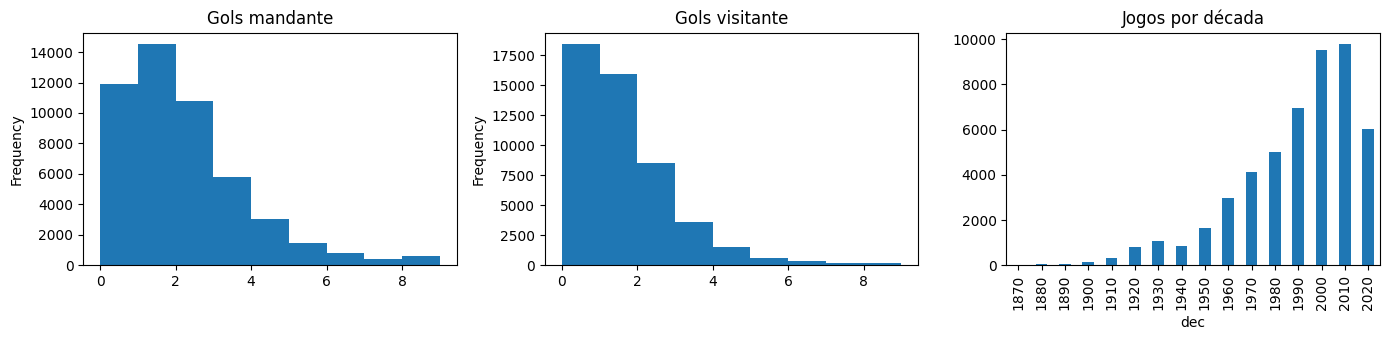

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
hist.home_score.clip(upper=8).plot.hist(bins=range(0, 10), ax=axes[0], title="Gols mandante")
hist.away_score.clip(upper=8).plot.hist(bins=range(0, 10), ax=axes[1], title="Gols visitante")
(hist.assign(dec=hist.date.dt.year // 10 * 10).dec.value_counts().sort_index()
     .plot.bar(ax=axes[2], title="Jogos por década"))
fig.tight_layout()
plt.show()

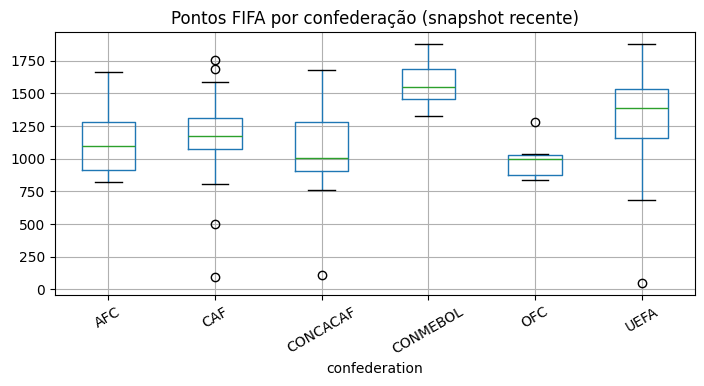

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
rank_latest.boxplot(column="total_points", by="confederation", ax=ax, rot=30)
ax.set_title("Pontos FIFA por confederação (snapshot recente)")
plt.suptitle("")
plt.show()

## §5.5 · Sinais preditivos candidatos (E4)

Medir, de forma exploratória, o que separa os desfechos — sem tocar no gabarito e usando só informação pré-jogo.

Com mando (não-neutro) 1/X/2: {'home': 0.507, 'away': 0.264, 'draw': 0.229}
Campo neutro          1/X/2: {'home': 0.442, 'away': 0.334, 'draw': 0.224}


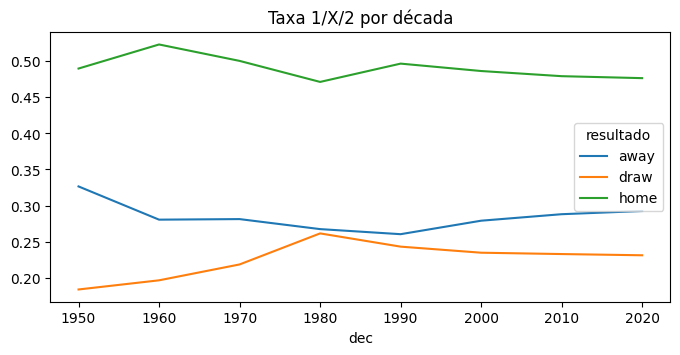

In [10]:
# Vantagem de mando: campo com mando vs. neutro
casa = hist[~hist.neutral]
neutro = hist[hist.neutral]
print("Com mando (não-neutro) 1/X/2:", casa.resultado.value_counts(normalize=True).round(3).to_dict())
print("Campo neutro          1/X/2:", neutro.resultado.value_counts(normalize=True).round(3).to_dict())

trend = (hist.assign(dec=hist.date.dt.year // 10 * 10)
             .pivot_table(index="dec", columns="resultado", aggfunc="size", fill_value=0))
trend = trend.div(trend.sum(axis=1), axis=0)
trend.loc[1950:].plot(title="Taxa 1/X/2 por década", figsize=(8, 3.5))
plt.show()

In [11]:
# Gols e Poisson: a taxa de empate observada bate com a de uma Poisson independente?
from scipy.stats import poisson
lam_h, lam_a = hist.home_score.mean(), hist.away_score.mean()
k = np.arange(0, 12)
p_draw_pois = float(np.sum(poisson.pmf(k, lam_h) * poisson.pmf(k, lam_a)))
p_draw_obs = float((hist.home_score == hist.away_score).mean())
print(f"Média de gols  mandante={lam_h:.2f}  visitante={lam_a:.2f}")
print(f"P(empate) observada={p_draw_obs:.3f}  vs  Poisson independente={p_draw_pois:.3f}")
print("Diferença motiva ajuste tipo Dixon-Coles (dependência em placares baixos).")

Média de gols  mandante=1.76  visitante=1.18
P(empate) observada=0.227  vs  Poisson independente=0.235
Diferença motiva ajuste tipo Dixon-Coles (dependência em placares baixos).


In [12]:
# Ranking como sinal: junção AS-OF (último rank ANTES do jogo, sem vazamento), desde 1993
h93 = hist[hist.date >= "1993-01-01"].copy().reset_index(drop=True)
h93["mid"] = np.arange(len(h93))
long = pd.concat([
    h93[["mid", "date", "home_team"]].rename(columns={"home_team": "team"}).assign(side="home"),
    h93[["mid", "date", "away_team"]].rename(columns={"away_team": "team"}).assign(side="away"),
])
long["key"] = long.team.map(canon)
long = long.sort_values("date")
r = ranking[["rank_date", "country_full", "rank"]].dropna(subset=["rank_date"]).copy()
r["key"] = r.country_full.map(canon)
r = r.sort_values("rank_date")
m = pd.merge_asof(long, r[["rank_date", "key", "rank"]], left_on="date",
                  right_on="rank_date", by="key", direction="backward")
h93["rank_home"] = h93.mid.map(m[m.side == "home"].set_index("mid")["rank"])
h93["rank_away"] = h93.mid.map(m[m.side == "away"].set_index("mid")["rank"])
h93 = h93.dropna(subset=["rank_home", "rank_away"])
h93["diff"] = h93.rank_away - h93.rank_home  # > 0: mandante melhor ranqueado
h93["venceu_mandante"] = (h93.resultado == "home").astype(int)
faixas = pd.cut(h93["diff"], [-300, -50, -20, -5, 5, 20, 50, 300])
display(h93.groupby(faixas, observed=True).venceu_mandante.mean().round(3)
            .rename("P(vitória mandante) por diferença de ranking"))

diff
(-300, -50]    0.152
(-50, -20]     0.307
(-20, -5]      0.395
(-5, 5]        0.462
(5, 20]        0.523
(20, 50]       0.640
(50, 300]      0.804
Name: P(vitória mandante) por diferença de ranking, dtype: float64

In [13]:
# Viabilidade de Elo pré-jogo: separação dos desfechos pela diferença de Elo
from collections import defaultdict
elo = defaultdict(lambda: 1500.0)
diffs, outs = [], []
HFA, K = 60.0, 20.0
sub = hist.sort_values("date")[["home_team", "away_team", "resultado"]]
for ht, at, res in sub.itertuples(index=False):
    rh, ra = elo[ht] + HFA, elo[at]
    exp_h = 1.0 / (1.0 + 10 ** ((ra - rh) / 400))
    diffs.append(rh - ra)
    outs.append(res)
    score_h = 1.0 if res == "home" else (0.5 if res == "draw" else 0.0)
    elo[ht] += K * (score_h - exp_h)
    elo[at] += K * ((1 - score_h) - (1 - exp_h))
elo_df = pd.DataFrame({"elo_diff": diffs, "win": [o == "home" for o in outs]})
faixas_elo = pd.cut(elo_df.elo_diff, [-600, -200, -75, 75, 200, 600])
display(elo_df.groupby(faixas_elo, observed=True).win.mean().round(3)
            .rename("P(vitória mandante) por Elo pré-jogo"))
print("Top 8 por Elo atual:", sorted(((canon(t), round(v)) for t, v in elo.items()),
                                      key=lambda x: -x[1])[:8])

elo_diff
(-600, -200]    0.074
(-200, -75]     0.210
(-75, 75]       0.394
(75, 200]       0.596
(200, 600]      0.796
Name: P(vitória mandante) por Elo pré-jogo, dtype: float64

Top 8 por Elo atual: [('argentina', 1985), ('spain', 1973), ('france', 1938), ('brazil', 1918), ('colombia', 1892), ('portugal', 1891), ('england', 1881), ('germany', 1870)]


**A aprofundar (E4, ver `tarefas.md`):** forma recente (janela móvel com `shift` para não vazar o próprio jogo), dias de descanso/viagem entre partidas, e amistoso vs. competitivo na ponderação.

## §5.6 · Aplicabilidade ao 2026 (E5)

Há dados suficientes onde o modelo vai prever? Cobertura por seleção e por confronto.

In [14]:
# Jogos recentes (desde 2018) por seleção de 2026
recent = hist[hist.date >= "2018-01-01"]
cnt = pd.Series(0, index=sorted(S))
for t in pd.concat([recent.home_team, recent.away_team]):
    k = canon(t)
    if k in cnt.index:
        cnt[k] += 1
cov = canon_2026.assign(jogos_recentes=canon_2026.key.map(cnt)).sort_values("jogos_recentes")
print("Seleções com menos jogos recentes:")
display(cov[["selecao", "confederation", "rank", "jogos_recentes"]].head(8))

# Confrontos de 2026 com H2H prévio disponível
h2h_keys = {(canon(a), canon(b)) for a, b in h2h[["home", "away"]].itertuples(index=False)}
cal = calendario.assign(kh=calendario.home.map(canon), ka=calendario.away.map(canon))
tem = cal.apply(lambda r: (r.kh, r.ka) in h2h_keys or (r.ka, r.kh) in h2h_keys, axis=1)
print("Confrontos de 2026 com H2H prévio:", int(tem.sum()), "/", len(cal))
print("Equilíbrio por confederação (2026):", canon_2026.confederation.value_counts(dropna=False).to_dict())

Seleções com menos jogos recentes:


,selecao,confederation,rank,jogos_recentes
27,New Zealand,OFC,85.0,53
17,Curaçao,CONCACAF,76.0,61
12,Haiti,CONCACAF,83.0,69
29,Cabo Verde,CAF,69.0,74
46,Ghana,CAF,74.0,79
7,Paraguay,CONMEBOL,40.0,80
14,Australia,AFC,27.0,82
35,Norway,UEFA,31.0,83


Confrontos de 2026 com H2H prévio: 14 / 72
Equilíbrio por confederação (2026): {'UEFA': 16, 'CAF': 10, 'AFC': 9, 'CONCACAF': 6, 'CONMEBOL': 6, 'OFC': 1}


## §5.7 · Síntese e ponte para o `01_features` (E6)

### Features candidatas (definir no `01`, todas **só com info pré-jogo**)

| Feature | Fonte | Observação |
|---|---|---|
| Diferença de ranking FIFA | ranking (as-of) | só ≥1993; último rank antes do jogo |
| Diferença de Elo pré-jogo | histórico | computar em ordem cronológica |
| Forma recente (janela móvel) | histórico | `shift` para não vazar o próprio jogo |
| Mando / campo neutro | histórico + sedes 2026 | anfitriões com mando; demais neutro |
| Confronto direto (H2H) | h2h / histórico | esparso — usar com cautela |
| Força ofensiva/defensiva | histórico | base p/ modelo de placar (Poisson/Dixon-Coles) |
| Descanso / congestionamento | datas | dias desde o último jogo |

### Riscos a vigiar
- **Vazamento temporal** (o maior): toda feature usa só o passado do jogo.
- **Ruído de amistosos** (dominam o histórico) → ponderar/filtrar.
- **Ranking só desde 1993** e **H2H esparso**.
- **Nomenclatura** de seleções (manter o mapa único da skill).
- **Campo neutro** em 2026 muda o significado de "mando".

> Taxas-base e baselines de referência: skill `avaliar-previsoes`. Próximos passos: [`docs/eda/tarefas.md`](../docs/eda/tarefas.md).